# Timoshenko Element on a Stepped Shaft Under Distributed Loads: Verification and GCI Mesh Convergence

**Case:** `stepped_shafts / distributed_load / case_distributed_gear_parabolic`
**Study type:** code and solution verification
**Status:** provisional — GCI thresholds to be confirmed

## Questions

1. How far is the Timoshenko FEM solution on the minimal mesh from the
   exact solution of the same equations, for a stepped shaft loaded by
   uniform (gear mesh) and parabolic (user) distributed loads?
2. Which mesh is required for the quantities of interest — the maximum
   resultant deflection and the absolute deviation of the resultant
   bending moment — to be converged, according to the Grid Convergence
   Index (GCI)?
3. Does the GCI estimate actually bound the true discretisation error?
   This can be checked here because the exact solution is known.

## Verification vs. validation

*Verification* establishes that the code solves the equations of the
model correctly; *validation* establishes that the model represents
reality adequately (ASME V&V 10; Roache, 1998). This notebook addresses
verification only: the reference is the exact solution of the same
equations.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import analytical_solution as an
import case_definition as cd
import figures as fg
from axisforge.results.convergence_results.convergence_results import ConvergenceRecord
from axisforge.solvers.machine_elements.shaft.fem_solvers.global_solver.rigid_support import (
    RigidSupportFEMSolver,
)
from axisforge.solvers.machine_elements.shaft.fem_solvers.submodel_solver.lagrange_multipliers import (
    SubmodelSolver,
)
from axisforge.solvers.mesh.convergence_solver import (
    MeshConvergenceStudy,
    build_mesh_refinement_result,
)

try:
    from axisforge_bridge.outputs.solver_results import convergence_report as crep
except ImportError as exc:  # the bridge must be importable (design-studies root on the path)
    raise ImportError(
        "axisforge_bridge is not importable. Install the design-studies repository "
        "(pip install -e <AxisForge-Design-Studies>) or start Jupyter with "
        "PYTHONPATH=<AxisForge-Design-Studies>."
    ) from exc

fg.use_style()
pd.set_option("display.float_format", lambda v: f"{v:.6g}")

segs = cd.segments()
system = cd.build_system()
SHAFT = "shaft1"   # change to "shaft2" to repeat the study for the second shaft
shaft_sys = next(ss for ss in system.shafts if ss.name == SHAFT)
SETTINGS = cd.THEORIES["timoshenko/cowper"]
KAPPA = an.kappa_cowper(cd.POISSON)
exact = an.solve_shaft(shaft_sys, segs, KAPPA, cd.SHAFT_LENGTH_MM)
exact_eb = an.solve_shaft(shaft_sys, segs, None, cd.SHAFT_LENGTH_MM)
SUPPORTS = (cd.BALL_POSITION_MM, cd.ROLLER_POSITION_MM)

## 1. Reference solution

The shaft is statically determinate, so the reactions and the bending
moment follow from equilibrium alone (`analytical_solution.py`):

$$ M(x) = \sum_k F_k \langle x - x_k\rangle
        + \sum_j \int_{a_j}^{\min(x,\,b_j)} q_j(s)\,(x - s)\,ds, \qquad
   V(x) = -\frac{dM}{dx}, $$

with the reactions among the point forces $F_k$ and the distributed loads
$q_j$ on $[a_j, b_j]$. The kinematics are integrated section by section,

$$ \frac{d\theta}{dx} = \frac{M}{EI(x)}, \qquad
   \frac{dv}{dx} = \theta + \frac{V}{\kappa G A(x)}, $$

with $\theta$ and $v$ continuous at the shoulders and $v(x_A) = v(x_B) = 0$.
Between breakpoints $M$ is a polynomial (degree 2 under the uniform gear
load, degree 4 under the parabolic load), represented and integrated
exactly; the solution is exact to round-off. The second term of
$dv/dx$ is the shear contribution: it always adds to the bending
deflection.

## 2. Timoshenko on the minimal mesh vs. the analytical solution

In [2]:
base = cd.solve(system, SETTINGS)[SHAFT]          # minimal mesh: mandatory nodes only
x = np.asarray(base.x)
xd = np.linspace(0.0, cd.SHAFT_LENGTH_MM, 2001)

def rel_max_err(fem, ref):
    return float(np.max(np.abs(np.asarray(fem) - ref)) / np.max(np.abs(ref)))

pd.DataFrame(
    {"FEM (minimal mesh)": [len(base.x_nodes), base.v_max, base.M_max],
     "analytical": [np.nan, float(np.max(exact.v(xd))), float(np.max(exact.M(xd)))]},
    index=["nodes", "v_res,max / mm", "M_res,max / N·mm"],
).assign(**{"max. nodal error / max|ref|": [np.nan, rel_max_err(base.v, exact.v(x)),
                                             rel_max_err(base.M, exact.M(x))]})

,FEM (minimal mesh),analytical,max. nodal error / max|ref|
nodes,18,NaN,NaN
"v_res,max / mm",0.095646,0.0999862,0.048475
"M_res,max / N·mm",180195,183635,0.380687


**Equilibrium check.** The sum of the FEM reactions must balance the
resultant of every applied load, in both planes (this would expose, for
instance, a gear load silently dropped by the solver):

In [3]:
from axisforge.core.loads import LoadPlane
rows = []
for plane, attr in ((LoadPlane.XY, "xy"), (LoadPlane.XZ, "xz")):
    applied = sum(float(ld.resultant_component(plane)) for ld in shaft_sys.distributed_radial_loads)
    applied += sum(float(ld.component(plane)) for ld in shaft_sys.radial_loads)
    reac = sum(getattr(b, f"Fr_{attr}") for b in base.bearing_nodes)
    rows.append((attr, applied, reac, applied + reac))
pd.DataFrame(rows, columns=["plane", "applied / N", "reactions / N", "residual / N"])

,plane,applied / N,reactions / N,residual / N
0,xy,1819.85,-1819.85,-1.81444e-10
1,xz,3000,-3000,-3.15595e-10


The FEM curve joins the nodal values with straight lines, which is the
displacement field of the two-node linear element itself (exact per bending
plane; for the resultant it is a close approximation). The lower panel shows
the deviation of that interpolated field from the exact solution along the
whole shaft, with the nodal values marked.

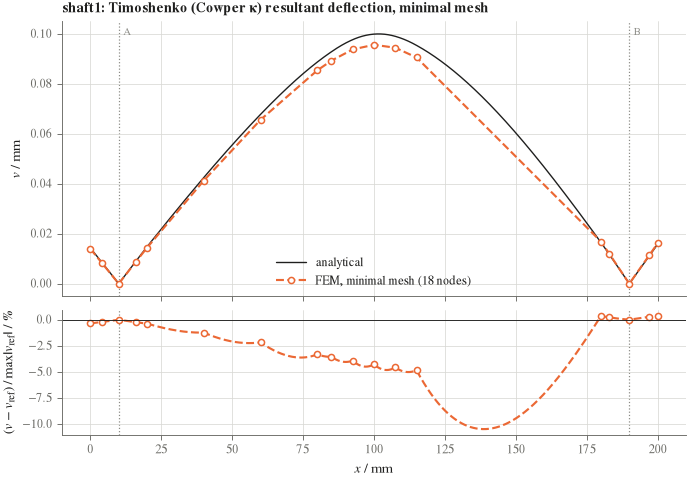

In [4]:
v_fem_xd = np.interp(xd, x, base.v)           # linear-element interpolation between nodes
scale = np.max(exact.v(xd))
fig_base = fg.field_comparison(
    [fg.Series(label="analytical", x=xd, y=exact.v(xd), color="#1f1f1e", linestyle="-",
               kwargs=dict(linewidth=0.9)),
     fg.Series(label=f"FEM, minimal mesh ({len(base.x_nodes)} nodes)", x=x, y=base.v,
               color="#eb6834", linestyle="--", marker="o")],
    [fg.Series(label="", x=xd, y=100 * (v_fem_xd - exact.v(xd)) / scale,
               color="#eb6834", linestyle="--"),
     fg.Series(label="", x=x, y=100 * (np.asarray(base.v) - exact.v(x)) / scale,
               color="#eb6834", linestyle="none", marker="o")],
    title=f"{SHAFT}: Timoshenko (Cowper κ) resultant deflection, minimal mesh",
    ylabel=r"$v$ / mm",
    delta_label=r"$(v - v_\mathrm{ref})\,/\,\max|v_\mathrm{ref}|$ / %",
    supports=SUPPORTS, support_names=("A", "B"),
)

## 3. GCI mesh convergence study

### 3.1 Procedure

The convergence study uses the AxisForge machinery unchanged:

- **Domain:** the supported span $[x_A, x_B] = [10, 190]$ mm, solved as a
  submodel (`SubmodelSolver`), with the displacements and rotations of the
  minimal-mesh global solution prescribed at the two cut nodes.
- **Refinement:** `Grader` bisects every element of the base mesh at each
  grade (`grade_0` = base nodes in the span, `grade_k` = $2^k$ times as many
  elements), so the refinement ratio is constant, $r = 2$.
- **Quantities of interest** (evaluation forms of `convergence_solver.py`),
  computed on the resultant fields
  $v_\mathrm{res} = \sqrt{v_{xy}^2 + v_{xz}^2}$ and
  $M_\mathrm{res} = \sqrt{M_{xy}^2 + M_{xz}^2}$:
    - `v_res:max` — maximum resultant deflection;
    - `M_res:max_minus_mean` — absolute deviation between the maximum and
      the mean of the resultant moment over the span (robust to the shift of
      the moment peak between grades);
    - `M_res:max` — maximum resultant moment (included because, unlike the
      deviation, its exact value is known).
- **GCI** (Roache, 1998), for three consecutive grades $c, m, f$:

$$ p = \frac{\ln\!\left[(f_c - f_m)/(f_m - f_f)\right]}{\ln r}, \qquad
   \mathrm{GCI}_{fm} = \frac{F_s\,|e_{fm}|}{r^p - 1}, \qquad
   e_{fm} = \frac{f_f - f_m}{f_m}. $$

A quantity is converged when $\mathrm{GCI}_{fm}$ and $\mathrm{GCI}_{mc}$ are
both below the threshold.

`SubmodelResult` has no resultant fields, so a thin read-only adapter
exposes `v_res` and `M_res` to `MeshConvergenceStudy`; nothing in AxisForge
is modified.

In [5]:
# --- GCI parameters (to be confirmed by the author) -------------------------
V_REQUESTS = [("v_res", "max")]
M_REQUESTS = [("M_res", "max_minus_mean"), ("M_res", "max")]
V_GCI_THRESHOLD, V_SAFETY_FACTOR = 0.01, 1.25   # 1 %, Fs = 1.25 (asymptotic range)
M_GCI_THRESHOLD, M_SAFETY_FACTOR = 0.02, 3.0    # 2 %, Fs = 3.0  (conservative)
MAX_LEVELS = 5   # grade_0 ... grade_4; grade_5 merges nodes closer than MESH_MIN_NODE_DIST_MM (r != 2)


class ResultantView:
    """Read-only view of a SubmodelResult adding the resultant fields."""

    def __init__(self, result):
        self._r = result
        self.x_nodes = result.x_nodes
        self.v_res = np.hypot(result.v_xz, result.v_xy)
        self.M_res = np.hypot(result.M_xz, result.M_xy)

    def __getattr__(self, name):
        return getattr(self._r, name)


x_lo, x_hi = sorted(b.position for b in shaft_sys.bearings)
submodel = SubmodelSolver(x_lo, x_hi)

v_study = MeshConvergenceStudy(V_REQUESTS, gci_threshold=V_GCI_THRESHOLD,
                               safety_factor=V_SAFETY_FACTOR)
m_study = MeshConvergenceStudy(M_REQUESTS, gci_threshold=M_GCI_THRESHOLD,
                               safety_factor=M_SAFETY_FACTOR)
v_rec = v_study.new_record("span_v_res", x_lo, x_hi)
m_rec = m_study.new_record("span_M_res", x_lo, x_hi)

grades: dict[str, ResultantView] = {}
for level in range(MAX_LEVELS):
    grade = f"grade_{level}"
    grades[grade] = ResultantView(submodel.solve(base, shaft_sys, SETTINGS, grade))
    if not v_rec.converged:
        v_study.add_level(v_rec, grade, grades[grade])
    if not m_rec.converged:
        m_study.add_level(m_rec, grade, grades[grade])
    if v_rec.converged and m_rec.converged:
        break

last = grades[grade]
for rec, study in ((v_rec, v_study), (m_rec, m_study)):
    if not rec.converged:
        study.finalize_unconverged(rec, last)

refinement = build_mesh_refinement_result(SHAFT, {v_rec.label: v_rec, m_rec.label: m_rec})

### 3.2 GCI results — deflection

In [6]:
print(crep.interval_block(v_rec))

  Interval 'span_v_res'  [10.000, 190.000] mm  -- CONVERGED
    final mesh: 105 node(s)

level    v_res:max [mm]  GCI_v_res:max
-------  --------------  -------------
grade_0  0.0956459951    --           
grade_1  0.0989144163    --           
grade_2  0.0998038199    0.420195%    
grade_3  0.1000086550    0.076763%    

  Richardson GCI detail (per transition, per metric):
transition                 metric     unit  r         p         delta_m_c  delta_f_m  e_m_c      e_f_m      GCI_m_c    GCI_f_m    f_h0          converged
-------------------------  ---------  ----  --------  --------  ---------  ---------  ---------  ---------  ---------  ---------  ------------  ---------
grade_0->grade_1->grade_2  v_res:max  mm    2.000000  1.877684  3.268e-03  8.894e-04  3.417207%  0.899165%  1.596917%  0.420195%  0.1001363264  False    
grade_1->grade_2->grade_3  v_res:max  mm    2.000000  2.118375  8.894e-04  2.048e-04  0.899165%  0.205238%  0.336308%  0.076763%  0.1000699453  True     

  Ric

### 3.3 GCI results — bending moment

In [7]:
print(crep.interval_block(m_rec))

  Interval 'span_M_res'  [10.000, 190.000] mm  -- NOT CONVERGED (stopped after 5 level(s))
    final mesh: 209 node(s)

level    M_res:max_minus_mean [N.mm]  M_res:max [N.mm]   GCI_M_res:max_minus_mean  GCI_M_res:max
-------  ---------------------------  -----------------  ------------------------  -------------
grade_0  98223.3119297698             180194.8618171498  --                        --           
grade_1  98500.9602761533             183117.1160268872  --                        --           
grade_2  97331.4563941875             183569.1815552965  n/a                       0.135539%    
grade_3  96710.2638764833             183754.2776337498  2.169168%                 0.209727%    
grade_4  96340.8730190895             183787.5111588394  1.680979%                 0.011874%    

  Richardson GCI detail (per transition, per metric):
transition                 metric                unit  r         p         delta_m_c   delta_f_m   e_m_c       e_f_m       GCI_m_c    GCI_f_m    f

## 4. Does the GCI bound the true error?

For each quantity with a known exact value, the true relative error of the
fine grade, $|f_f - f_\mathrm{exact}|/|f_\mathrm{exact}|$, is compared with
the GCI estimate $\mathrm{GCI}_{fm}$ of the same transition, and the
Richardson-extrapolated value $f_{h0}$ is compared with the exact value.

**Richardson extrapolation.** Assuming $f(h) = f_0 + C\,h^p$ in the asymptotic
range, the three grades give the mesh-independent estimate from the finest
pair:

$$ f_{h0} = f_f + \frac{f_f - f_m}{r^p - 1}. $$

**Admissibility.** The GCI and $f_{h0}$ are defined only for $p > 0$. A
transition with $0 < (f_c - f_m)/(f_m - f_f) \le 1$ (differences between grades
not decreasing) has $p \le 0$, is outside the asymptotic range and is reported
as `n/a`, not converged, in the tables of Section 3.

In [8]:
exact_values = {
    "v_res:max": float(np.max(exact.v(np.linspace(x_lo, x_hi, 180_001)))),
    "M_res:max": float(np.max(exact.M(np.linspace(x_lo, x_hi, 180_001)))),
}
rows = []
for rec in (v_rec, m_rec):
    for i, gci_dict in enumerate(rec.gci_history):
        f_c, f_m, f_f = (rec.point_metrics_history[i + k] for k in range(3))
        for name, gci in gci_dict.items():
            if name not in exact_values or not hasattr(gci, "p"):
                continue
            f_ex = exact_values[name]
            rows.append({
                "metric": name,
                "transition": f"{rec.levels[i]}→{rec.levels[i + 2]}",
                "p": gci.p,
                "GCI_fm / %": 100 * gci.GCI_f_m,
                "true error f_f / %": 100 * abs(f_f[name] - f_ex) / abs(f_ex),
                "GCI bounds error": 100 * gci.GCI_f_m >= 100 * abs(f_f[name] - f_ex) / abs(f_ex),
                "f_h0 (Richardson)": gci.f_h0,
                "exact": f_ex,
                "f_h0 error / %": 100 * abs(gci.f_h0 - f_ex) / abs(f_ex),
            })
gci_check = pd.DataFrame(rows)
gci_check

,metric,transition,p,GCI_fm / %,true error f_f / %,GCI bounds error,f_h0 (Richardson),exact,f_h0 error / %
0,v_res:max,grade_0→grade_2,1.87768,0.420195,0.182439,True,0.100136,0.0999862,0.150113
1,v_res:max,grade_1→grade_3,2.11838,0.0767635,0.0224238,True,0.10007,0.0999862,0.0837225
2,M_res:max,grade_0→grade_2,2.69248,0.135539,0.0360286,True,183652,183635,0.00902365
3,M_res:max,grade_1→grade_3,1.28826,0.209727,0.0647669,True,183883,183635,0.134651
4,M_res:max,grade_2→grade_4,2.47756,0.0118737,0.0828644,False,183795,183635,0.0868249


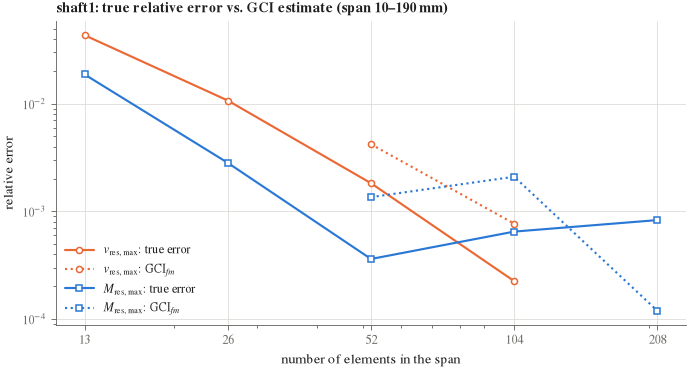

In [9]:
def true_error_series(rec, name, label, color, ls, marker):
    n_el = [len(grades[g].x_nodes) - 1 for g in rec.levels]
    err = [abs(h[name] - exact_values[name]) / exact_values[name] for h in rec.point_metrics_history]
    return fg.Series(label=label, x=n_el, y=err, color=color, linestyle=ls, marker=marker)

def gci_series(rec, name, label, color, ls, marker):
    n_el = [len(grades[g].x_nodes) - 1 for g in rec.levels[2:]]
    gci = [g[name].GCI_f_m for g in rec.gci_history]
    return fg.Series(label=label, x=n_el, y=gci, color=color, linestyle=ls, marker=marker)

fig_gci = fg.convergence(
    [len(grades[g].x_nodes) - 1 for g in m_rec.levels],
    [true_error_series(v_rec, "v_res:max", r"$v_\mathrm{res,max}$: true error", "#eb6834", "-", "o"),
     gci_series(v_rec, "v_res:max", r"$v_\mathrm{res,max}$: GCI$_{fm}$", "#eb6834", ":", "o"),
     true_error_series(m_rec, "M_res:max", r"$M_\mathrm{res,max}$: true error", "#2a78d6", "-", "s"),
     gci_series(m_rec, "M_res:max", r"$M_\mathrm{res,max}$: GCI$_{fm}$", "#2a78d6", ":", "s")],
    title=f"{SHAFT}: true relative error vs. GCI estimate (span {x_lo:.0f}–{x_hi:.0f} mm)",
    ylabel="relative error",
    xlabel=r"number of elements in the span",
    reference_orders={},
)
_ = fig_gci.axes[0].legend(loc="lower left")

### 4.1 Error inherited from the base solution

The submodel prescribes, at its two cut nodes, the displacements **and
rotations** of the global solution on the minimal mesh. At a pin support the
rotation is not a boundary condition of the real problem; prescribing the
rotation of a coarse solution imposes its discretisation error on the
submodel. The submodel then converges to a limit that differs from the
exact solution, and the GCI — which measures only the convergence *within*
the submodel — cannot detect that difference.
The figure above shows it for `M_res:max`: the true error decreases up to
grade 2 and then grows again, as the submodel values approach the biased
limit rather than the exact one.

In [10]:
theta_rows = []
for b in base.bearing_nodes:
    for plane in ("xy", "xz"):
        th_fem = getattr(b, f"theta_{plane}")
        th_ex = float(getattr(exact, plane).theta(b.position))
        theta_rows.append((b.label, plane, th_fem, th_ex, 100 * (th_fem / th_ex - 1) if th_ex else np.nan))
display(pd.DataFrame(theta_rows, columns=["bearing", "plane", "θ prescribed (minimal mesh) / rad",
                                          "θ exact / rad", "deviation / %"]))

v_last = v_rec.gci_history[-1]["v_res:max"]
bias_extrap = 100 * (v_last.f_h0 / exact_values["v_res:max"] - 1)
display(Markdown(
    f"Richardson-extrapolated limit of the submodel sequence: **{v_last.f_h0:.6f} mm**; "
    f"exact maximum deflection: **{exact_values['v_res:max']:.6f} mm**; difference "
    f"**{bias_extrap:+.3f} %**. This is the error inherited from the base solution. It is "
    f"below the 1 % threshold here, but it is a systematic bias, not a discretisation error "
    f"of the submodel, and it does not decrease with the submodel grade."
))

,bearing,plane,θ prescribed (minimal mesh) / rad,θ exact / rad,deviation / %
0,shaft1_ball_locating,xy,0.000684093,0.00070183,-2.52725
1,shaft1_ball_locating,xz,0.00121792,0.00124883,-2.47528
2,shaft1_roller_nonlocating,xy,-0.000717449,-0.00070183,2.2254
3,shaft1_roller_nonlocating,xz,-0.00144997,-0.00141383,2.55613


Richardson-extrapolated limit of the submodel sequence: **0.100070 mm**; exact maximum deflection: **0.099986 mm**; difference **+0.084 %**. This is the error inherited from the base solution. It is below the 1 % threshold here, but it is a systematic bias, not a discretisation error of the submodel, and it does not decrease with the submodel grade.

### 4.2 Behaviour of `max_minus_mean`

`max_minus_mean` subtracts the **arithmetic mean of the nodal values**,
not the spatial mean of $M(x)$. On a non-uniform base mesh (element lengths
from 3 to 65 mm here) the nodes are concentrated near the bearings and the
gear, so the nodal mean is a mesh-weighted average that changes with the
node distribution. The quantity converges slowly and with an observed order
below the theoretical one (Section 3.3), and grade 5 could not be used: the
bisection produces nodes closer than `MESH_MIN_NODE_DIST_MM`, which are
merged, so the refinement ratio is no longer 2. A spatial mean,
$\frac{1}{x_B - x_A}\int M\,dx$ (e.g. trapezoidal), would remove the
dependence on node distribution.

## 5. Production solve on the converged mesh

The converged node sets of both records are merged
(`MeshRefinementResult.all_extra_nodes`) and the whole shaft is re-solved
with them as extra mandatory nodes.

In [11]:
extra = refinement.all_extra_nodes
converged = RigidSupportFEMSolver(SETTINGS).solve(shaft_sys, extra_mandatory=extra)
eb = cd.solve(system, cd.THEORIES["euler_bernoulli"])[SHAFT]   # deflection nodally exact on any mesh
xc = np.asarray(converged.x)

summary = pd.DataFrame(
    {"minimal mesh": [len(base.x_nodes), base.v_max, base.M_max,
                      rel_max_err(base.v, exact.v(x))],
     "converged mesh": [len(converged.x_nodes), converged.v_max, converged.M_max,
                        rel_max_err(converged.v, exact.v(xc))],
     "analytical": [np.nan, exact_values["v_res:max"], exact_values["M_res:max"], np.nan]},
    index=["nodes", "v_res,max / mm", "M_res,max / N·mm", "max. nodal error in v / max|v|"],
)
summary

,minimal mesh,converged mesh,analytical
nodes,18,213,NaN
"v_res,max / mm",0.095646,0.0999681,0.0999862
"M_res,max / N·mm",180195,183617,183635
max. nodal error in v / max|v|,0.048475,0.000189603,NaN


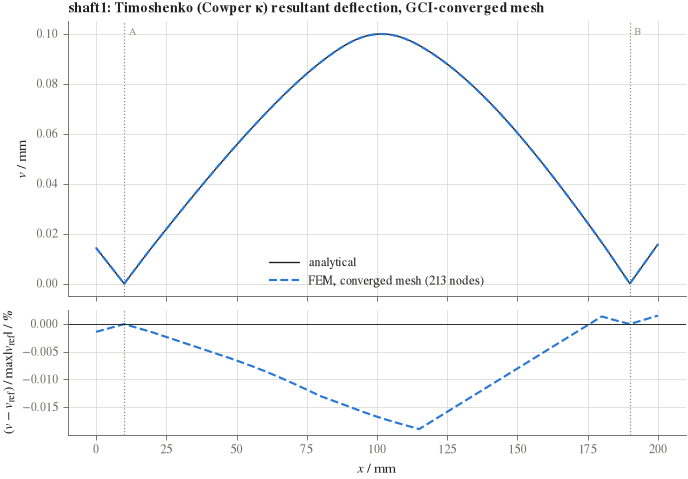

In [12]:
fig_conv = fg.field_comparison(
    [fg.Series(label="analytical", x=xd, y=exact.v(xd), color="#1f1f1e", linestyle="-",
               kwargs=dict(linewidth=0.9)),
     fg.Series(label=f"FEM, converged mesh ({len(converged.x_nodes)} nodes)", x=xc,
               y=converged.v, color="#2a78d6", linestyle="--")],
    [fg.Series(label="", x=xc, y=100 * (np.asarray(converged.v) - exact.v(xc)) / np.max(exact.v(xd)),
               color="#2a78d6", linestyle="--")],
    title=f"{SHAFT}: Timoshenko (Cowper κ) resultant deflection, GCI-converged mesh",
    ylabel=r"$v$ / mm",
    delta_label=r"$(v - v_\mathrm{ref})\,/\,\max|v_\mathrm{ref}|$ / %",
    supports=SUPPORTS, support_names=("A", "B"),
)

## 6. Conclusions

In [13]:
def last_valid(rec, name):
    """Last transition with a real (non-placeholder) GCI for this metric."""
    for g in reversed(rec.gci_history):
        if hasattr(g[name], "p"):
            return g[name]
    return None

def status(rec):
    return "converged" if rec.converged else f"**NOT converged** after {len(rec.levels)} grades"

shear_effect = 100 * (converged.v_max / eb.v_max - 1)
shear_exact = 100 * (np.max(exact.v(xd)) / np.max(exact_eb.v(xd)) - 1)
v_gci = last_valid(v_rec, "v_res:max")
m_gci = last_valid(m_rec, "M_res:max_minus_mean")
mm_gci = last_valid(m_rec, "M_res:max")
bad = gci_check[~gci_check["GCI bounds error"]]
unbounded_text = "" if bad.empty else " ".join(
    f"In `{r.metric}` ({r.transition}) the true error ({r['true error f_f / %']:.3f} %) exceeds "
    f"the GCI ({r['GCI_fm / %']:.3f} %): the fine grade has already reached the biased limit."
    for _, r in bad.iterrows())
display(Markdown(f"""
1. On the minimal mesh ({len(base.x_nodes)} nodes) the Timoshenko deflection deviates from
   the exact solution by **{100 * rel_max_err(base.v, exact.v(x)):.1f} %**; the reactions balance
   the applied loads (Section 2).
2. `v_res:max`: {status(v_rec)} at {v_rec.levels[-1]} (GCI$_{{fm}}$ = {100 * v_gci.GCI_f_m:.3f} %,
   observed order p = {v_gci.p:.2f}, theoretical 2).
3. `M_res`: {status(m_rec)}. `M_res:max` converges well (last GCI$_{{fm}}$ =
   {100 * mm_gci.GCI_f_m:.3f} %), but `M_res:max_minus_mean` does not reach the 2 % criterion on
   both transitions (last GCI$_{{fm}}$ = {100 * m_gci.GCI_f_m:.2f} %, p = {m_gci.p:.2f}), because
   its nodal mean depends on the node distribution (Section 4.2).
4. The GCI bounds the true error in {int(gci_check["GCI bounds error"].sum())} of {len(gci_check)}
   transitions with a known exact value (Section 4). {unbounded_text} The submodel sequence
   converges to a limit {bias_extrap:+.3f} % away from the exact deflection, an error inherited
   from the rotations prescribed by the coarse base solution (Section 4.1) that the GCI cannot
   detect.
5. On the converged mesh ({len(converged.x_nodes)} nodes, global solve) the deflection error drops
   to **{100 * rel_max_err(converged.v, exact.v(xc)):.4f} %**, and the shear effect relative to
   Euler–Bernoulli is **{shear_effect:+.2f} %** (exact: {shear_exact:+.2f} %).
"""))


1. On the minimal mesh (18 nodes) the Timoshenko deflection deviates from
   the exact solution by **4.8 %**; the reactions balance
   the applied loads (Section 2).
2. `v_res:max`: converged at grade_3 (GCI$_{fm}$ = 0.077 %,
   observed order p = 2.12, theoretical 2).
3. `M_res`: **NOT converged** after 5 grades. `M_res:max` converges well (last GCI$_{fm}$ =
   0.012 %), but `M_res:max_minus_mean` does not reach the 2 % criterion on
   both transitions (last GCI$_{fm}$ = 1.68 %, p = 0.75), because
   its nodal mean depends on the node distribution (Section 4.2).
4. The GCI bounds the true error in 4 of 5
   transitions with a known exact value (Section 4). In `M_res:max` (grade_2→grade_4) the true error (0.083 %) exceeds the GCI (0.012 %): the fine grade has already reached the biased limit. The submodel sequence
   converges to a limit +0.084 % away from the exact deflection, an error inherited
   from the rotations prescribed by the coarse base solution (Section 4.1) that the GCI cannot
   detect.
5. On the converged mesh (213 nodes, global solve) the deflection error drops
   to **0.0190 %**, and the shear effect relative to
   Euler–Bernoulli is **+5.00 %** (exact: +4.95 %).


## References

- ASME V&V 10-2019, *Standard for Verification and Validation in
  Computational Solid Mechanics*.
- Roache, P. J. (1998). *Verification and Validation in Computational
  Science and Engineering*. Hermosa Publishers — GCI and Richardson
  extrapolation.
- Celik, I. B. et al. (2008). Procedure for estimation and reporting of
  uncertainty due to discretization in CFD applications. *J. Fluids Eng.*
  130(7), 078001.
- Cowper (1966); Hutchinson (2001) — see notebook 01.